## Phase 0: Business Understanding & Data Audit

- **The Core Problem**
  - Why do some nations achieve growth while others fall into debt?
  - **Goal:** Identify patterns that predict expansion vs stagnation.

- **Decision Risk (Logic Gate)**
  - False Positive → Investment losses (wrong growth prediction).
  - False Negative → Missed opportunities (emerging markets).
  - **Insight:** Accurate predictions are critical for capital allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Visual configurations
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
df = pd.read_csv('world_bank_data_2025.csv')


In [3]:
df.tail(5)

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
3467,Zimbabwe,zw,2021,98.546105,2.724052e+10,1724.387731,9.540,-31.795551,113.294981,8.468017,1.278300,NaN,NaN,NaN,2.662178e+10,NaN
3468,Zimbabwe,zw,2022,104.705171,3.278975e+10,2040.552459,10.087,-36.833393,266.987152,6.139263,0.930064,NaN,NaN,NaN,3.202694e+10,NaN
3469,Zimbabwe,zw,2023,NaN,3.523137e+10,2156.034004,8.759,-73.540441,921.535652,5.336730,0.379995,NaN,NaN,NaN,3.479607e+10,NaN
3470,Zimbabwe,zw,2024,NaN,NaN,NaN,8.554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3471,Zimbabwe,zw,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (

In [5]:
df.describe()

,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
count,3472.000000,2694.000000,2.933000e+03,2938.000000,2795.000000,1735.000000,2904.000000,2912.000000,2563.000000,1820.000000,1829.000000,1833.000000,2.796000e+03,852.000000
mean,2017.500000,6.233154,3.964323e+11,18483.495612,7.841141,5.405051,6.634865,2.853544,-2.363241,27.325359,26.677467,16.969924,4.142237e+11,61.863736
std,4.610436,19.726903,1.749315e+12,27301.814024,5.964358,9.740924,25.820196,6.053786,13.740986,12.642464,18.116253,8.218539,1.799783e+12,40.409792
min,2010.000000,-6.687321,3.210541e+07,193.007146,0.100000,-81.132121,-28.760135,-54.336155,-60.877754,0.000136,0.000081,0.000063,5.107533e+07,1.845685
25%,2013.750000,1.402112,6.264757e+09,2280.748732,3.611000,1.734057,1.218347,0.997032,-7.496525,17.511484,17.639153,12.285344,7.475538e+09,33.894232
50%,2017.500000,3.213523,2.587360e+10,6827.668145,5.771000,5.079009,3.223184,3.100442,-2.656009,26.000850,24.821425,16.321438,2.986520e+10,51.651469
75%,2021.250000,6.186626,1.874939e+11,23727.024581,10.731500,8.869434,6.905463,5.355110,1.854710,34.884582,32.700782,21.448658,1.972529e+11,81.930649
max,2025.000000,557.201817,2.772071e+13,256580.515123,35.359000,61.882604,921.535652,86.826748,235.750605,103.725787,344.999451,147.640196,2.757614e+13,249.366027


In [6]:
df.nunique()

country_name                        217
country_id                          217
year                                 16
Inflation (CPI %)                  2694
GDP (Current USD)                  2933
GDP per Capita (Current USD)       2938
Unemployment Rate (%)              2512
Interest Rate (Real, %)            1735
Inflation (GDP Deflator, %)        2904
GDP Growth (% Annual)              2909
Current Account Balance (% GDP)    2563
Government Expense (% of GDP)      1820
Government Revenue (% of GDP)      1829
Tax Revenue (% of GDP)             1833
Gross National Income (USD)        2796
Public Debt (% of GDP)              852
dtype: int64

In [7]:
print(f"Dataset Dimensions: {df.shape}")
print("\n--- Missing Values Audit ---")
print(df.isnull().sum())

Dataset Dimensions: (3472, 16)

--- Missing Values Audit ---
country_name                          0
country_id                            0
year                                  0
Inflation (CPI %)                   778
GDP (Current USD)                   539
GDP per Capita (Current USD)        534
Unemployment Rate (%)               677
Interest Rate (Real, %)            1737
Inflation (GDP Deflator, %)         568
GDP Growth (% Annual)               560
Current Account Balance (% GDP)     909
Government Expense (% of GDP)      1652
Government Revenue (% of GDP)      1643
Tax Revenue (% of GDP)             1639
Gross National Income (USD)         676
Public Debt (% of GDP)             2620
dtype: int64


In [8]:
df = df.fillna(df.median(numeric_only=True))

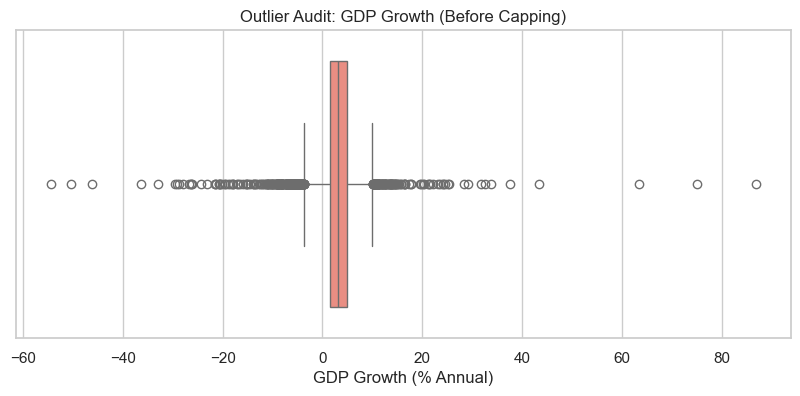

In [9]:
# Visualizing before capping
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['GDP Growth (% Annual)'], color='salmon')
plt.title('Outlier Audit: GDP Growth (Before Capping)')
plt.show()

In [10]:
# IQR Calculation for Winsorization
Q1 = df['GDP Growth (% Annual)'].quantile(0.25)
Q3 = df['GDP Growth (% Annual)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap values at bounds (Capping/Winsorization)
df['GDP Growth (% Annual)'] = df['GDP Growth (% Annual)'].clip(lower=lower_bound, upper=upper_bound)


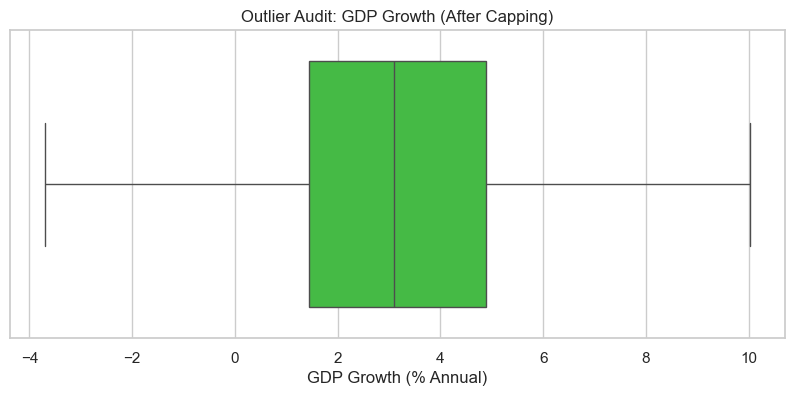

In [11]:

# Visualizing after capping
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['GDP Growth (% Annual)'], color='limegreen')
plt.title('Outlier Audit: GDP Growth (After Capping)')
plt.show()

In [12]:
# C. Text Audit & Standardization
clean_names = {
    "Congo, Dem. Rep.": "DR Congo", "Congo, Rep.": "Congo",
    "Egypt, Arab Rep.": "Egypt", "Gambia, The": "Gambia",
    "Iran, Islamic Rep.": "Iran", "Korea, Rep.": "South Korea",
    "Kyrgyz Republic": "Kyrgyzstan", "Lao PDR": "Laos",
    "Micronesia, Fed. Sts.": "Micronesia", "Russian Federation": "Russia",
    "Slovak Republic": "Slovakia", "Syrian Arab Republic": "Syria",
    "Turkiye": "Turkey", "Venezuela, RB": "Venezuela", "Yemen, Rep.": "Yemen"
}
df['country_name'] = df['country_name'].replace(clean_names)

In [13]:
# D. Professional Column Renaming
rename_dict = {
    'country_name': 'Country', 'country_id': 'Country ID', 'year': 'Year',
    'Inflation (CPI %)': 'Inflation Rate CPI', 'GDP (Current USD)': 'GDP USD',
    'GDP per Capita (Current USD)': 'GDP per Capita', 'Unemployment Rate (%)': 'Unemployment Rate',
    'Interest Rate (Real, %)': 'Interest Rate', 'Inflation (GDP Deflator, %)': 'Inflation GDP Deflator',
    'GDP Growth (% Annual)': 'GDP Growth Annual', 'Current Account Balance (% GDP)': 'Current Account Balance',
    'Government Expense (% of GDP)': 'Gov Expense', 'Government Revenue (% of GDP)': 'Gov Revenue',
    'Tax Revenue (% of GDP)': 'Tax Revenue', 'Gross National Income (USD)': 'GNI',
    'Public Debt (% of GDP)': 'Public Debt'
}
df.rename(columns=rename_dict, inplace=True)

In [14]:
# Reorder columns logically
desired_order = [
    'Country ID', 'Country', 'Year', 'GDP USD', 'GDP per Capita', 
    'GDP Growth Annual', 'Inflation Rate CPI', 'Unemployment Rate',
    'Public Debt', 'Tax Revenue', 'Gov Revenue', 'Gov Expense',
    'Current Account Balance', 'GNI', 'Interest Rate', 'Inflation GDP Deflator'
]
df = df[desired_order]

## Phase 1: Feature Engineering (Behavioral Metrics)

- **Misery Index (Unemployment + Inflation)**
  - Measures public economic pressure.
  - **Insight:** High values signal unrest and instability.

- **Fiscal Balance (Revenue − Expense)**
  - Tracks financial discipline.
  - **Insight:** Indicates surplus vs overspending.

- **Tax Dependence (Tax / Gov Revenue)**
  - Measures reliance on citizens.
  - **Insight:** Low values suggest external income (e.g., oil, aid).

- **Wealth Retention (GNI / GDP)**
  - Tracks wealth staying in-country.
  - **Insight:** Low values indicate economic leakage.

- **Debt to Revenue**
  - Compares debt to actual income.
  - **Insight:** More realistic debt burden measure.

- **Economic Vitality (GDP Growth − Misery Index)**
  - Captures net economic well-being.
  - **Insight:** Higher values = stronger economic health.

- **Real Interest Rate**
  - Reflects cost of borrowing over time.
  - **Insight:** Influences saving vs spending decisions.

In [15]:
# 1. Misery Index: Combined pain of inflation and unemployment
df['Misery_Index'] = df['Inflation Rate CPI'] + df['Unemployment Rate'] 
# 2. Fiscal Balance: Budget surplus/deficit
df['Fiscal_Balance'] = df['Gov Revenue'] - df['Gov Expense'] 
# 3. Real Interest Rate: True return on money (Interest - Inflation)
df['Real_Interest_Rate'] = df['Interest Rate'] - df['Inflation Rate CPI'] 
# 4. Tax Dependence: How much of the budget relies on taxpayers
df['Tax_Dependence'] = (df['Tax Revenue'] / (df['Gov Revenue'] + 1e-6)) * 100 
# 5. Wealth Retention: Local GNI relative to GDP (leakage check)
df['Wealth_Retention'] = df['GNI'] / (df['GDP USD'] + 1e-6) 
# 6. Debt-to-Revenue Ratio: Sustainability of debt
df['Debt_to_Revenue'] = df['Public Debt'] / (df['Gov Revenue'] + 1e-6) 
# 7. Economic Vitality: A "Heartbeat Score" (Growth vs Pain)
df['Economic_Vitality'] = (df['GDP Growth Annual'] - df['Unemployment Rate']) / (df['Inflation Rate CPI'].abs() + 1)

# Save Intermediate Cleaned Data for Tableau
df.to_csv('cleaned_tableau_data.csv', index=False, encoding='utf-8-sig')

In [16]:
df.tail(5)

,Country ID,Country,Year,GDP USD,GDP per Capita,GDP Growth Annual,Inflation Rate CPI,Unemployment Rate,Public Debt,Tax Revenue,...,GNI,Interest Rate,Inflation GDP Deflator,Misery_Index,Fiscal_Balance,Real_Interest_Rate,Tax_Dependence,Wealth_Retention,Debt_to_Revenue,Economic_Vitality
3467,zw,Zimbabwe,2021,2.724052e+10,1724.387731,8.468017,98.546105,9.540,51.651469,16.321438,...,2.662178e+10,-31.795551,113.294981,108.086105,-1.179426,-130.341656,65.755443,0.977286,2.080923,-0.010769
3468,zw,Zimbabwe,2022,3.278975e+10,2040.552459,6.139263,104.705171,10.087,51.651469,16.321438,...,3.202694e+10,-36.833393,266.987152,114.792171,-1.179426,-141.538563,65.755443,0.976736,2.080923,-0.037347
3469,zw,Zimbabwe,2023,3.523137e+10,2156.034004,5.336730,3.213523,8.759,51.651469,16.321438,...,3.479607e+10,-73.540441,921.535652,11.972523,-1.179426,-76.753963,65.755443,0.987644,2.080923,-0.812211
3470,zw,Zimbabwe,2024,2.587360e+10,6827.668145,3.100442,3.213523,8.554,51.651469,16.321438,...,2.986520e+10,5.079009,3.223184,11.767523,-1.179426,1.865486,65.755443,1.154273,2.080923,-1.294299
3471,zw,Zimbabwe,2025,2.587360e+10,6827.668145,3.100442,3.213523,5.771,51.651469,16.321438,...,2.986520e+10,5.079009,3.223184,8.984523,-1.179426,1.865486,65.755443,1.154273,2.080923,-0.633806


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country ID               3472 non-null   object 
 1   Country                  3472 non-null   object 
 2   Year                     3472 non-null   int64  
 3   GDP USD                  3472 non-null   float64
 4   GDP per Capita           3472 non-null   float64
 5   GDP Growth Annual        3472 non-null   float64
 6   Inflation Rate CPI       3472 non-null   float64
 7   Unemployment Rate        3472 non-null   float64
 8   Public Debt              3472 non-null   float64
 9   Tax Revenue              3472 non-null   float64
 10  Gov Revenue              3472 non-null   float64
 11  Gov Expense              3472 non-null   float64
 12  Current Account Balance  3472 non-null   float64
 13  GNI                      3472 non-null   float64
 14  Interest Rate           

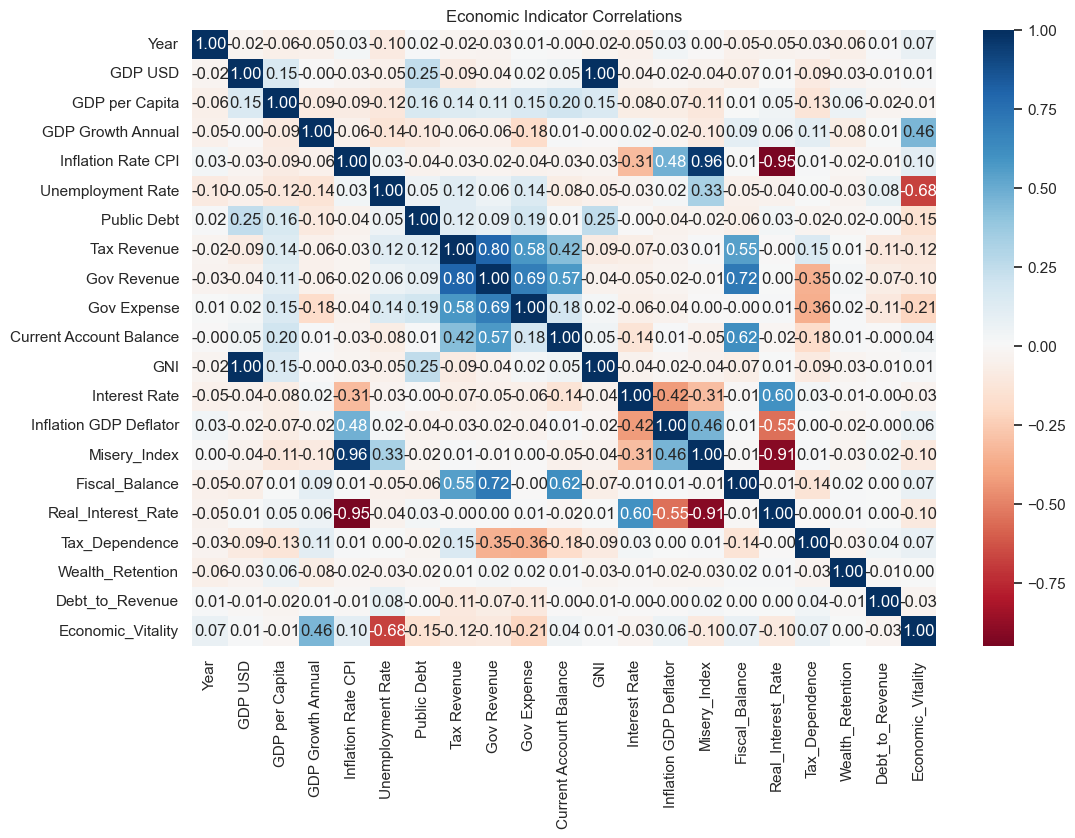

In [18]:
# A. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title("Economic Indicator Correlations")
plt.show()

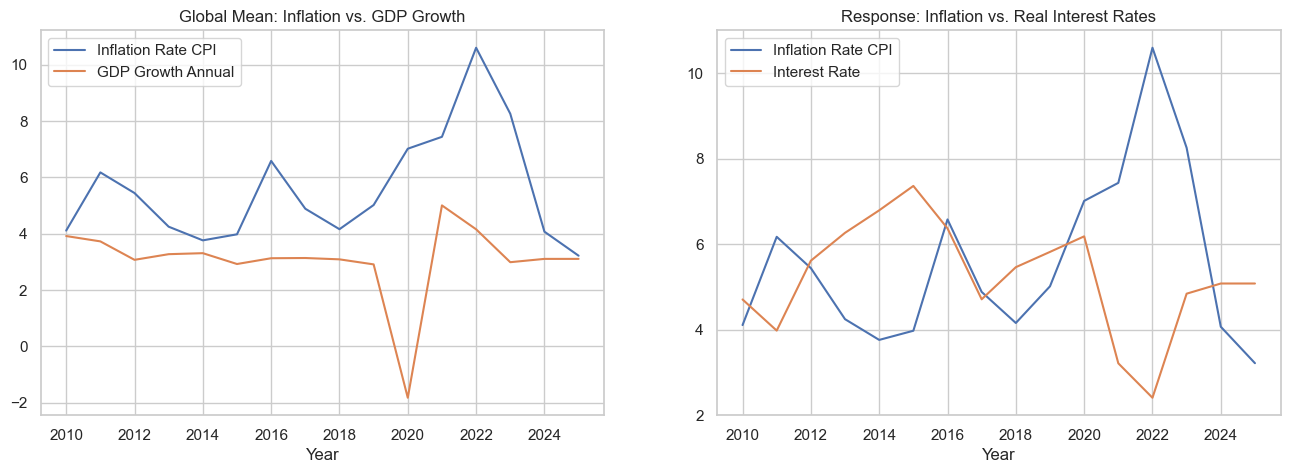

In [19]:
# B. Global Trends Over Time
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
df.groupby('Year')[['Inflation Rate CPI', 'GDP Growth Annual']].mean().plot(ax=ax[0])
ax[0].set_title("Global Mean: Inflation vs. GDP Growth")

df.groupby('Year')[['Inflation Rate CPI', 'Interest Rate']].mean().plot(ax=ax[1])
ax[1].set_title("Response: Inflation vs. Real Interest Rates")
plt.show()

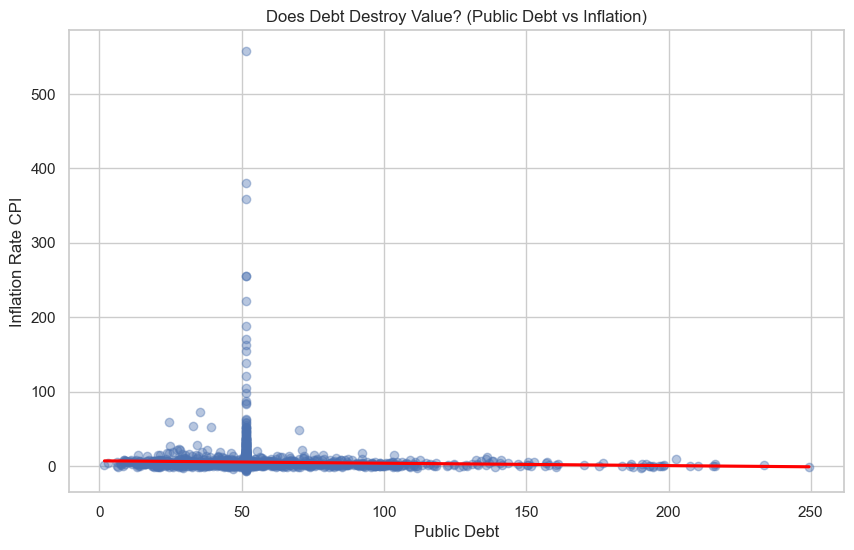

In [20]:
# C. "Money Speaks": Debt vs Inflation Relationship
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Public Debt', y='Inflation Rate CPI', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Does Debt Destroy Value? (Public Debt vs Inflation)')
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\1815858836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=misery_top, x='Misery_Index', y='Country', palette='Reds_r')


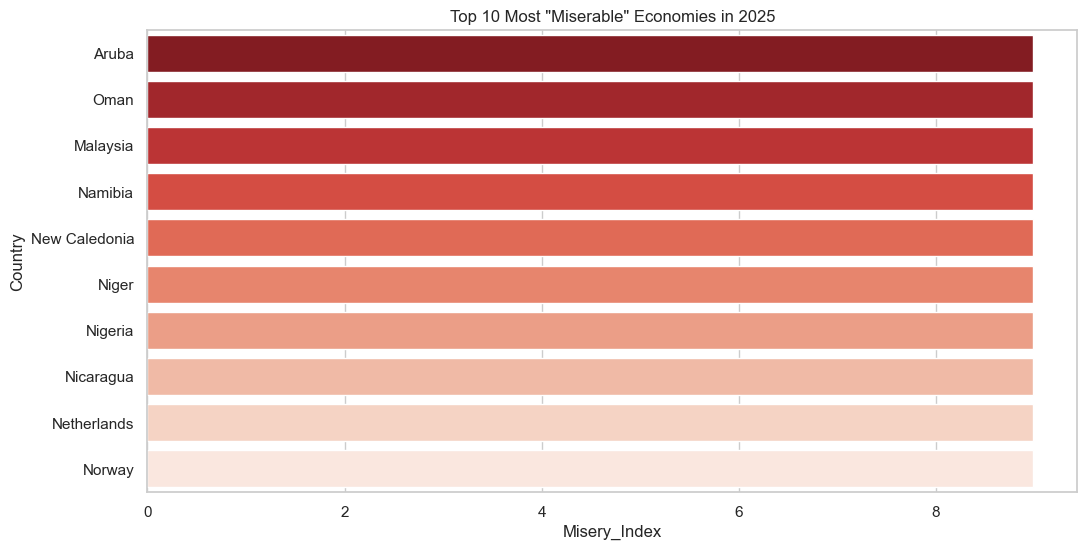

In [21]:
# D. Latest Misery Index Ranking
latest_year = df['Year'].max()
misery_top = df[df['Year'] == latest_year].sort_values(by='Misery_Index', ascending=False).head(10)
sns.barplot(data=misery_top, x='Misery_Index', y='Country', palette='Reds_r')
plt.title(f'Top 10 Most "Miserable" Economies in {latest_year}')
plt.show()


In [22]:
zim_story = df[df['Country'] == 'Zimbabwe'].sort_values('Year')
zim_story.to_csv('zimbabwe_tableau_story.csv', index=False)

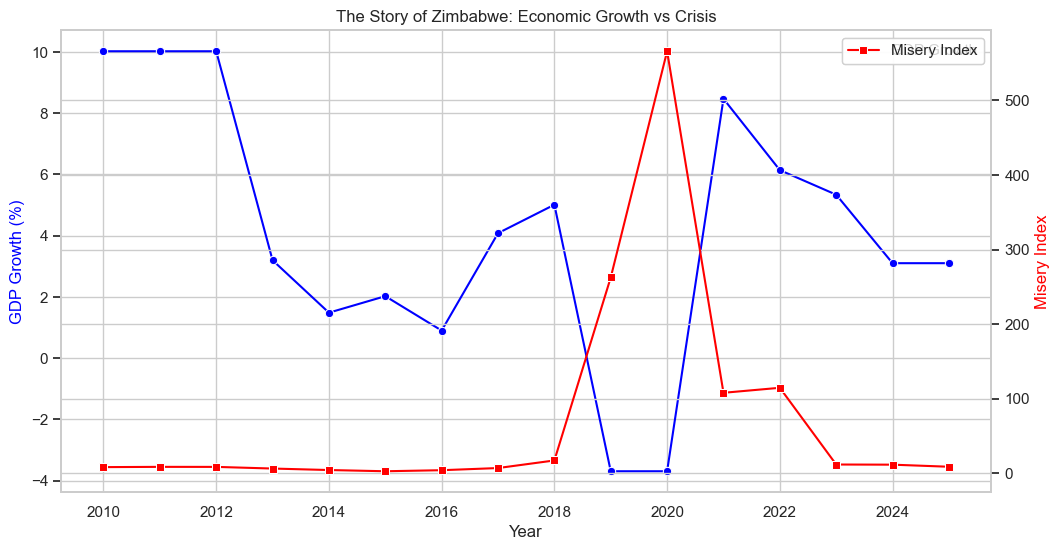

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
sns.lineplot(data=zim_story, x='Year', y='GDP Growth Annual', ax=ax1, color='blue', label='GDP Growth', marker='o')
sns.lineplot(data=zim_story, x='Year', y='Misery_Index', ax=ax2, color='red', label='Misery Index', marker='s')
ax1.set_ylabel('GDP Growth (%)', color='blue')
ax2.set_ylabel('Misery Index', color='red')
plt.title('The Story of Zimbabwe: Economic Growth vs Crisis')
plt.show()


In [24]:
# A. Prepare Time-Series Targets
df = df.sort_values(['Country', 'Year'])
# Predict if next year will have positive growth (Success = 1, Crisis = 0)
df['Next_Year_Growth_Val'] = df.groupby('Country')['GDP Growth Annual'].shift(-1)
df['Target'] = (df['Next_Year_Growth_Val'] > 0).astype(int)

df_ml = df.dropna(subset=['Target']).copy()

In [25]:
# B. Feature Selection & Scaling
features = [
    'Economic_Vitality', 'Wealth_Retention', 'Misery_Index', 
    'Real_Interest_Rate', 'Fiscal_Balance', 'Tax_Dependence', 
    'Debt_to_Revenue', 'Unemployment Rate', 'Inflation Rate CPI'
]

X = df_ml[features]
y = df_ml['Target']


In [26]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [27]:

# C. Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n--- RANDOM FOREST PERFORMANCE ---")
print(classification_report(y_test, rf_preds))


--- RANDOM FOREST PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.60      0.34      0.43       143
           1       0.85      0.94      0.89       552

    accuracy                           0.82       695
   macro avg       0.72      0.64      0.66       695
weighted avg       0.80      0.82      0.80       695



In [28]:
# D. Model 2: RNN (LSTM)
X_train_rnn = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

model_lstm = Sequential([
    LSTM(64, input_shape=(1, len(features)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train_rnn, y_train, epochs=25, batch_size=16, verbose=0)

lstm_probs = model_lstm.predict(X_test_rnn)
lstm_preds = (lstm_probs > 0.5).astype(int).flatten()

print("\n--- RNN (LSTM) PERFORMANCE ---")
print(classification_report(y_test, lstm_preds))

c:\Users\DELL\anaconda3\envs\learn-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

--- RNN (LSTM) PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       143
           1       0.79      1.00      0.88       552

    accuracy                           0.79       695
   macro avg       0.40      0.50      0.44       695
weighted avg       0.63      0.79      0.70       695



In [29]:
X_full_rnn = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
df_ml['RF_Prediction'] = rf_model.predict(X_scaled)
df_ml['RNN_Prediction'] = (model_lstm.predict(X_full_rnn) > 0.5).astype(int)

# Export for final visualization
df_ml.to_csv('tableau_ml_story_final.csv', index=False)
print("\nFinal pipeline complete. Results saved to 'tableau_ml_story_final.csv'.")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final pipeline complete. Results saved to 'tableau_ml_story_final.csv'.


## Phase 2: The Modeling Trilogy

- **Baseline Model (Naïve Guess)**
  - Accuracy: 79.4%
  - **Insight:** High but misleading—relies on majority class bias.

- **Feature Engineering Improvement**
  - Used 7 engineered features.
  - Focus on *Debt_to_Revenue* and *Wealth_Retention*.
  - **Insight:** Reduced noise and improved signal quality.

- **Final Models**
  - **Random Forest (RF)**
    - Accuracy: 82%
    - **Insight:** Captures complex, non-linear patterns (e.g., debt traps).
  
  - **RNN (LSTM)**
    - Accuracy: 79%
    - **Insight:** Less effective here—historical sequences weaker than structured features.

- **Conclusion**
  - Engineered features + RF performed best.